In [1]:
import pandas as pd # wczytywanie CSV i przeglądanie tabeli
import numpy as np # Operacje na liczbach (średnie, sumy)
import matplotlib.pyplot as plt # Wykresy (słupki, linie, histogramy)
import seaborn as sns # Ładniejsze wykresy statystyczne

print("Wszystko działa!")

Wszystko działa!


In [2]:
df = pd.read_csv("../data/application_train.csv")
print(f'dane wczytane: {df.shape}')
# df.shape - ile wierszy i kolumn ma ta tabela 
# (307511, 122) = 307,511 wierszy, 122 kolumny


dane wczytane: (307511, 122)


In [3]:
df.head()
# zwraca pierwsze 5 wierszy tabeli
# Domyślnie 5, ale możesz dać liczbę w nawiasie, np. df.head(10) żeby zobaczyć 10

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [5]:
description = pd.read_csv("../data/HomeCredit_columns_description.csv", encoding="latin-1")
description.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [6]:
df.info(verbose=True, show_counts=True)
# verbose=True mówi: pokaż mi każdą kolumnę z osobna, bez skracania.
# show_counts=True wymusza pokazanie „Non-Null Count" (ile wartości niepustych jest w każdej kolumnie).


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

| Klasa pozytywna | Ta którą próbujemy wykryć (u nas: TARGET=1, niespłacający) |
| Niezbalansowane klasy | Gdy jedna klasa jest dużo liczniejsza (u nas 92% vs 8%) |
| Accuracy paradox | Wysokie accuracy może być oszukańcze przy niezbalansowanych klasach |
| TP (True Positive) | Model trafił, że to klasa pozytywna |
| TN (True Negative) | Model trafił, że to klasa negatywna |
| FP (False Positive) | Model błędnie krzyknął "to ta klasa!" |
| FN (False Negative) | Model błędnie powiedział "to nie ta klasa" | GORSZE

Podejście 1: df["TARGET"]:
dostajesz całą kolumnę jako oddzielną „mini-tabelę"

Podejście 2: df.TARGET:
to samo, krótszy zapis (działa, ale tylko jak nazwa nie ma spacji)

Jak już masz kolumnę, to potem dorzucasz na końcu co chcesz z nią zrobić. Na przykład:

.sum() — dodaj wszystkie wartości
.mean() — średnia
.value_counts() — policz, ile razy występuje każda wartość

In [13]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

df["TARGET"].value_counts() — zwraca TABELKĘ z dwoma wartościami (0 i 1)

jest 24825 niespłacających'
a 282686 spłacających

In [ ]:
df["TARGET"].value_counts()[1] # tylko 1 zlicza

24825

In [22]:
df["TARGET"].value_counts(normalize=True)


TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

mamy procent z tego

0 jest 92%
1 jest 8%

<Axes: xlabel='TARGET', ylabel='count'>

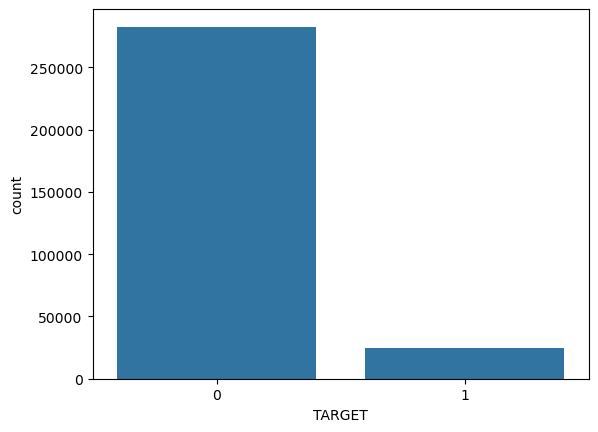

In [29]:
sns.countplot(data = df, x="TARGET")

C:\Users\adamc\AppData\Local\Temp\ipykernel_16028\1426130671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="TARGET", palette=["#2ecc71", "#e74c3c"])


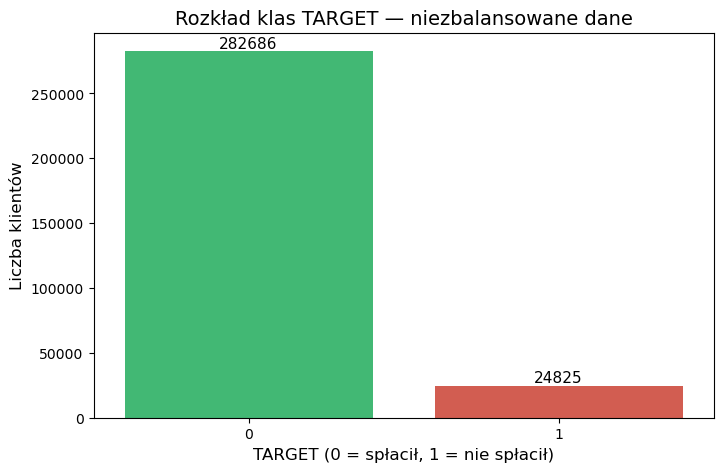

In [30]:
# Tworzymy wykres
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="TARGET", palette=["#2ecc71", "#e74c3c"])

# Tytuł i etykiety
plt.title("Rozkład klas TARGET — niezbalansowane dane", fontsize=14)
plt.xlabel("TARGET (0 = spłacił, 1 = nie spłacił)", fontsize=12)
plt.ylabel("Liczba klientów", fontsize=12)

# Dodajemy liczby na słupkach
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.show()


